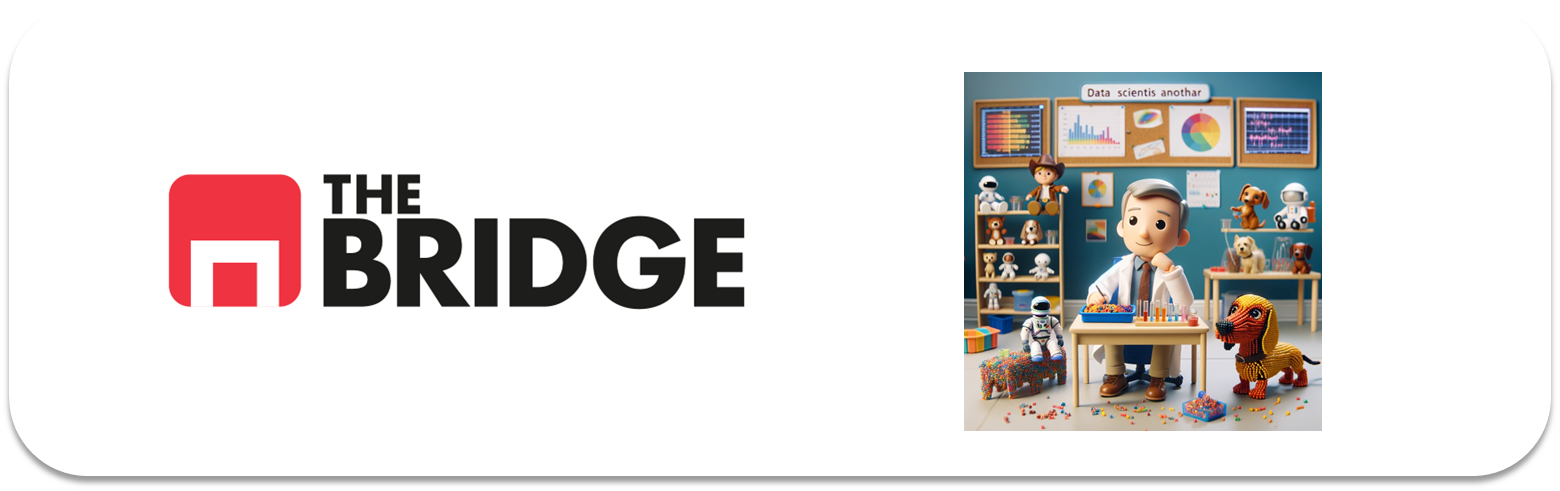

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [48]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np





### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [49]:
sns.get_dataset_names()

df_titanic = pd.DataFrame(sns.load_dataset('titanic'))

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [50]:
df_titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [51]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [52]:
df_titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [53]:
df_titanic.isnull().sum()/len(df_titanic)*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [54]:
df_titanic.drop(columns=['parch'], inplace=True)
df_titanic.head(10)

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [ ]:
# 1. Eliminar columna deck
df_titanic = df_titanic.drop(columns=['deck'])

# 2. Eliminar las 2 filas con nulos en embarked/embark_town
df_titanic = df_titanic.dropna(subset=['embarked', 'embark_town'])
#poner la moda en ambos
df_titanic.loc[df_titanic['embark_town'].isna(), 'embark_town'] = df_titanic['embarked'].mode()[0]


# 3. Rellenar age con la mediana en base a who
media_woman = df_titanic.loc[df_titanic['who'] == 'woman', 'age'].median()
media_man = df_titanic.loc[df_titanic['who'] == 'man', 'age'].median()
media_child = df_titanic.loc[df_titanic['who'] == 'child', 'age'].median()

df_titanic['age'] = df_titanic['age'].fillna(df_titanic['age'].median())

# Verificar que ya no hay nulos
df_titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [56]:
df_titanic.head(20)

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,28.0,0,8.4583,Q,Third,man,True,Queenstown,no,True
6,0,1,male,54.0,0,51.8625,S,First,man,True,Southampton,no,True
7,0,3,male,2.0,3,21.0750,S,Third,child,False,Southampton,no,False
8,1,3,female,27.0,0,11.1333,S,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,30.0708,C,Second,child,False,Cherbourg,yes,False


### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.




| Columna/Variable | Descripción |
| ---------------- | ----------- |
| -survived       | -Si sobrevivió o no (1 o 0) |
| -pclass       | -Clase del viaje |
| -sex       | -Género del pasajero/a |
| -age	       | -Edad del pasajero/a |
| -sibsp       | -Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros) |
| -fare       | -Precio del billete que pagó |
| -embarked       | -Inicial de la ciudad donde embarcó |
| -class       | -Clase sdel viaje |
| -who       | -Tipo de persona: hombre, mujer o niño |
| -adult_male       | -Si es hombre adulto o no(booleano)|
| -embark_town       | -Ciudad donde embarcó|
| -alive       | -Si sobrevivió o no |
| -alone       | -Si viajó solo o no |


### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [57]:
df_titanic['embarked'] = df_titanic['embarked'].replace({
    'S': 'Southampton',
    'Q': 'Queenstown',
    'C': 'Cherbourg'
})

In [58]:
df_titanic.head(19)

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,Southampton,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,Cherbourg,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,Southampton,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,Southampton,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,Southampton,Third,man,True,Southampton,no,True
5,0,3,male,28.0,0,8.4583,Queenstown,Third,man,True,Queenstown,no,True
6,0,1,male,54.0,0,51.8625,Southampton,First,man,True,Southampton,no,True
7,0,3,male,2.0,3,21.0750,Southampton,Third,child,False,Southampton,no,False
8,1,3,female,27.0,0,11.1333,Southampton,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,30.0708,Cherbourg,Second,child,False,Cherbourg,yes,False


In [ ]:
df_titanic = df_titanic.drop(columns=['embarked'])


In [61]:
df_titanic.head(19)

,survived,pclass,sex,age,sibsp,fare,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,71.2833,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,Third,man,True,Southampton,no,True
5,0,3,male,28.0,0,8.4583,Third,man,True,Queenstown,no,True
6,0,1,male,54.0,0,51.8625,First,man,True,Southampton,no,True
7,0,3,male,2.0,3,21.0750,Third,child,False,Southampton,no,False
8,1,3,female,27.0,0,11.1333,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,30.0708,Second,child,False,Cherbourg,yes,False


In [62]:
def pinta_distribucion_categoricas(df, columnas_categoricas, relativa=False, mostrar_valores=False):
    num_columnas = len(columnas_categoricas)
    num_filas = (num_columnas // 2) + (num_columnas % 2)

    fig, axes = plt.subplots(num_filas, 2, figsize=(15, 5 * num_filas))
    axes = axes.flatten() 

    for i, col in enumerate(columnas_categoricas):
        ax = axes[i]
        if relativa:
            total = df[col].value_counts().sum()
            serie = df[col].value_counts().apply(lambda x: x / total)
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia Relativa')
        else:
            serie = df[col].value_counts()
            sns.barplot(x=serie.index, y=serie, ax=ax, palette='viridis', hue = serie.index, legend = False)
            ax.set_ylabel('Frecuencia')

        ax.set_title(f'Distribución de {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if mostrar_valores:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    for j in range(i + 1, num_filas * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [ ]:
df_tipificacion = pd.DataFrame([df_titanic.nunique(), df_titanic.nunique()/len(df_titanic) * 100,
                                df_titanic.dtypes]).T.rename(columns = {0: "Card",\
1: "%_Card", 2: "Tipo"})
df_tipificacion

,Card,%_Card,Tipo
survived,2,0.224972,int64
pclass,3,0.337458,int64
sex,2,0.224972,str
age,88,9.898763,float64
sibsp,7,0.787402,int64
fare,247,27.784027,float64
class,3,0.337458,category
who,3,0.337458,str
adult_male,2,0.224972,bool
embark_town,3,0.337458,str


In [64]:
df_tipificacion["Clasificada_como"] = "Categorica" # PArtiendo de que casi todas parecen categóricas
df_tipificacion.loc[df_tipificacion.Card == 2, "Clasificada_como"] = "Binaria"
df_tipificacion.loc[df_tipificacion["Card"] > 10, "Clasificada_como"] ="Numerica Discreta"
df_tipificacion.loc[df_tipificacion["%_Card"] > 30, "Clasificada_como"] = "Numerica Continua"
df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
survived,2,0.224972,int64,Binaria
pclass,3,0.337458,int64,Categorica
sex,2,0.224972,str,Binaria
age,88,9.898763,float64,Numerica Discreta
sibsp,7,0.787402,int64,Categorica
fare,247,27.784027,float64,Numerica Discreta
class,3,0.337458,category,Categorica
who,3,0.337458,str,Categorica
adult_male,2,0.224972,bool,Binaria
embark_town,3,0.337458,str,Categorica


### #2.1 Categóricas

In [74]:
categoricas_titanic = [
    "survived", "sex", "class", "who", "embark_town", "alive", "alone"]

In [75]:
for catego in categoricas_titanic:
    print(f"Para {catego}")
    print(df_titanic[catego].value_counts())
    print("\n"*2)

Para survived
survived
0    549
1    340
Name: count, dtype: int64



Para sex
sex
male      577
female    312
Name: count, dtype: int64



Para class
class
Third     491
First     214
Second    184
Name: count, dtype: int64



Para who
who
man      537
woman    269
child     83
Name: count, dtype: int64



Para embark_town
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64



Para alive
alive
no     549
yes    340
Name: count, dtype: int64



Para alone
alone
True     535
False    354
Name: count, dtype: int64





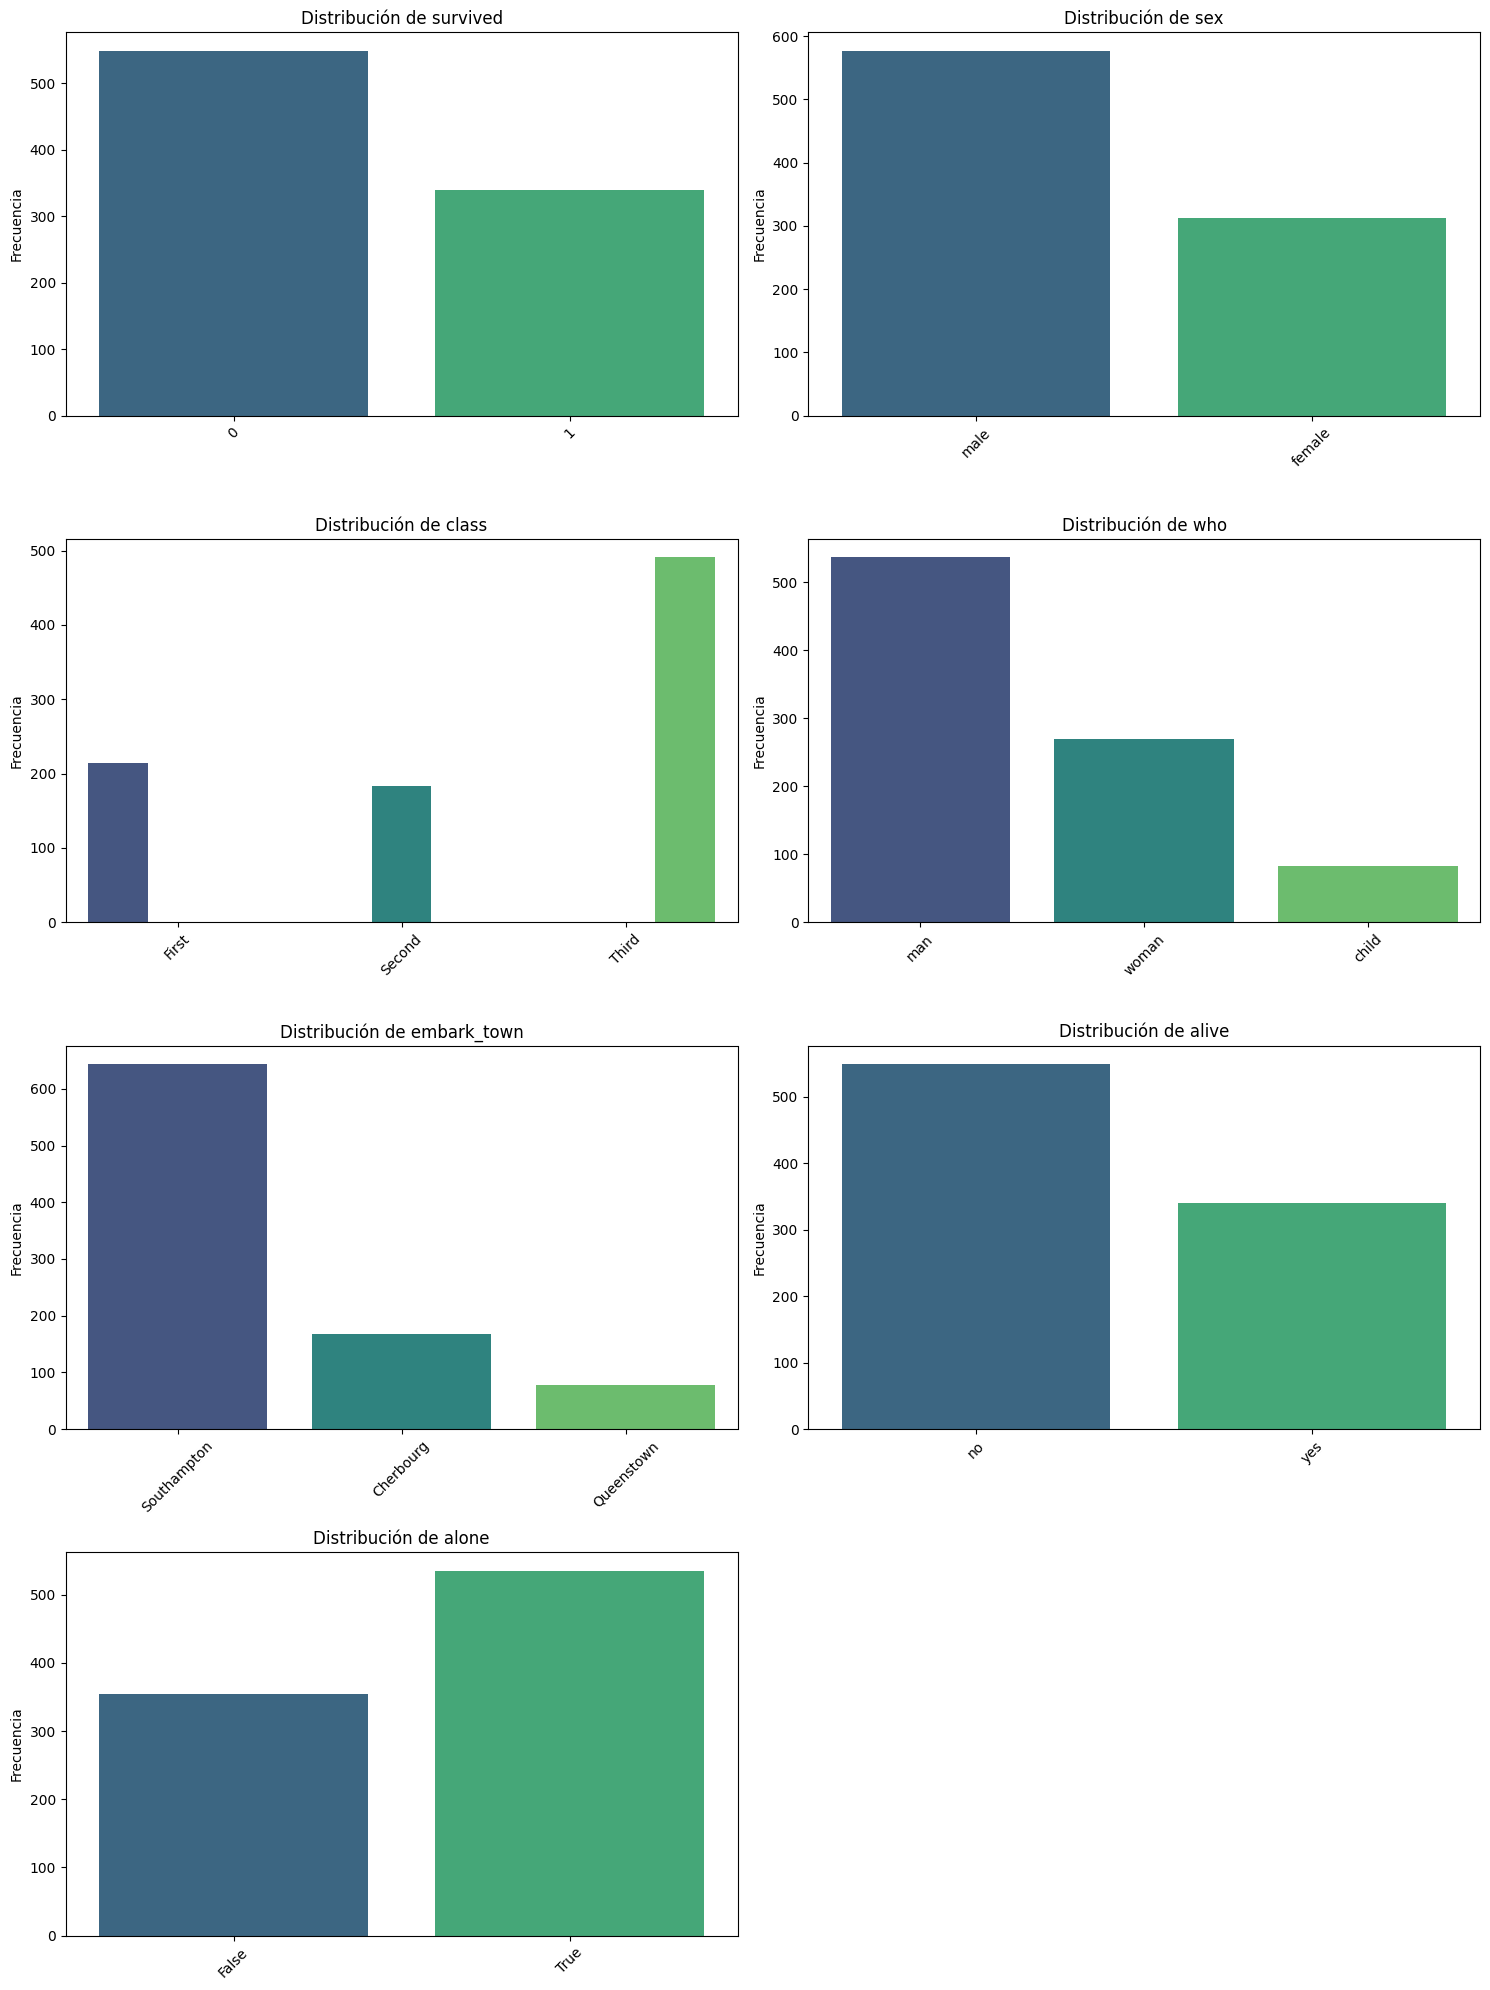

In [76]:
pinta_distribucion_categoricas(df_titanic, categoricas_titanic)

1. Diferencia claramente entre tercera clase y el resto
2. También entre hombres adultos y el resto
3. Diferencia entre los que sobrevivieron y los que no
4. Gran diferencia entre los que embarcaron en Southampton

In [ ]:
df_titanic[categoricas_titanic].mode()

,0
survived,0
sex,male
class,Third
who,man
embark_town,Southampton
alive,no
alone,True


1. Podríamos decir que el perfil más habitual sería: Hombre que falleció, de tercera clase, que viajaba solo y que embarcó en Southampton

### #2.2 Numéricas

In [77]:
numericas_titanic = [
    "age", "fare"]

In [78]:
df_titanic.describe().loc["mean"]

survived     0.382452
pclass       2.311586
age         29.315152
sibsp        0.524184
fare        32.096681
Name: mean, dtype: float64

In [79]:
df_titanic.describe().loc["50%"]

survived     0.0000
pclass       3.0000
age         28.0000
sibsp        0.0000
fare        14.4542
Name: 50%, dtype: float64

Aquí observo dos cosas:

1. Que por ejemplo, la edad es similar entre media y mediana. Podemos quedarnos con la media.
2. No obstante, el precio del billete varía mucho. Hay más dispersión. Por ejemplo, hay un precio máximo de 512

In [80]:
df_titanic.describe().loc["max"]

survived      1.0000
pclass        3.0000
age          80.0000
sibsp         8.0000
fare        512.3292
Name: max, dtype: float64

In [83]:
def plot_multiple_boxplots(df, columns, dim_matriz_visual = 2):
    num_cols = len(columns)
    num_rows = num_cols // dim_matriz_visual + num_cols % dim_matriz_visual
    fig, axes = plt.subplots(num_rows, dim_matriz_visual, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.boxplot(data=df, x=column, ax=axes[i])
            axes[i].set_title(column)

    # Ocultar ejes vacíos
    for j in range(i+1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [84]:
def plot_boxplot_grouped(df, column_to_plot, group_column):
    if df[column_to_plot].dtype in ['int64', 'float64'] and df[group_column].dtype in ['object', 'category']:
        sns.boxplot(data=df, x=group_column, y=column_to_plot)
        plt.show()

In [85]:
print(df_titanic["fare"].quantile(0.5),
    df_titanic["fare"].quantile(0.9), 
      df_titanic["fare"].quantile(0.95),
     df_titanic["fare"].max())

14.4542 77.2875 112.31831999999979 512.3292


In [86]:
df_titanic.describe()

,survived,pclass,age,sibsp,fare
count,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,32.096681
std,0.486260,0.834700,12.984932,1.103705,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,512.329200


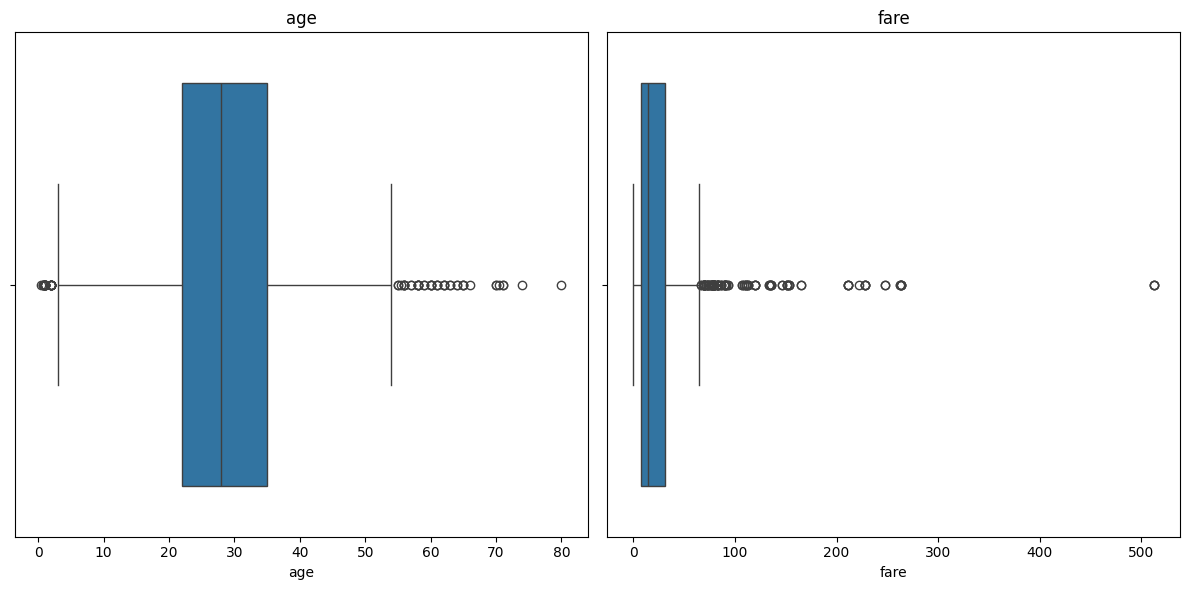

In [87]:
plot_multiple_boxplots(df_titanic, numericas_titanic)

1. Age. Distribución bastante normal. Pocos outliers. Ya lo vimos con media y mediana.
2. Fare. Muy desigual todo. Hay gente que pagó el billete muy caro comparado con la mayoría. Muchos outliers. 

In [88]:
df_titanic.describe().loc[["std", "mean"]].T

,std,mean
survived,0.486260,0.382452
pclass,0.834700,2.311586
age,12.984932,29.315152
sibsp,1.103705,0.524184
fare,49.697504,32.096681


In [89]:
def variabilidad(df):
    df_var = df.describe().loc[["std", "mean"]].T
    df_var["CV"] = df_var["std"]/df_var["mean"]
    return df_var

In [90]:
variabilidad(df_titanic)

,std,mean,CV
survived,0.486260,0.382452,1.271426
pclass,0.834700,2.311586,0.361094
age,12.984932,29.315152,0.442943
sibsp,1.103705,0.524184,2.105566
fare,49.697504,32.096681,1.548369


1. Observamos que Fare tiene mucha dispersión. Confirma la diferencia de precios y que la media no es representativa. 

In [91]:
def plot_histo_den(df, columns):
    num_cols = len(columns)
    num_rows = num_cols // 2 + num_cols % 2
    fig, axes = plt.subplots(num_rows, 2, figsize=(12, 6 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(columns):
        if df[column].dtype in ['int64', 'float64']:
            sns.histplot(df[column], kde=True, ax=axes[i])
            axes[i].set_title(f'Histograma y KDE de {column}')

    # Ocultar ejes vacíos
    for j in range(i + 1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

<Axes: >

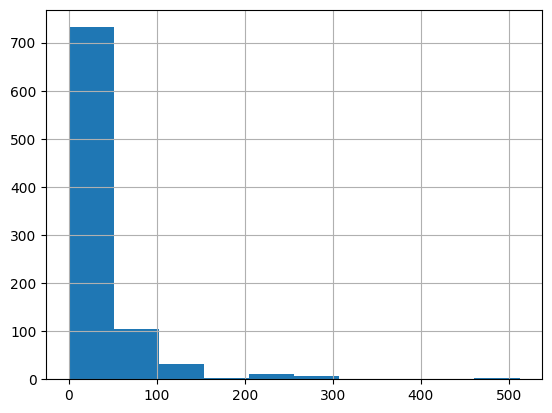

In [93]:
df_titanic["fare"].hist()

1. Se observa mucha dispersión y la distribución de valores se concentra mucho en un rango inicial. 

<Axes: >

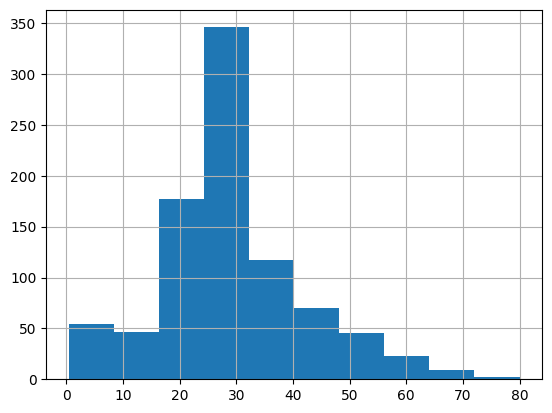

In [94]:
df_titanic["age"].hist()

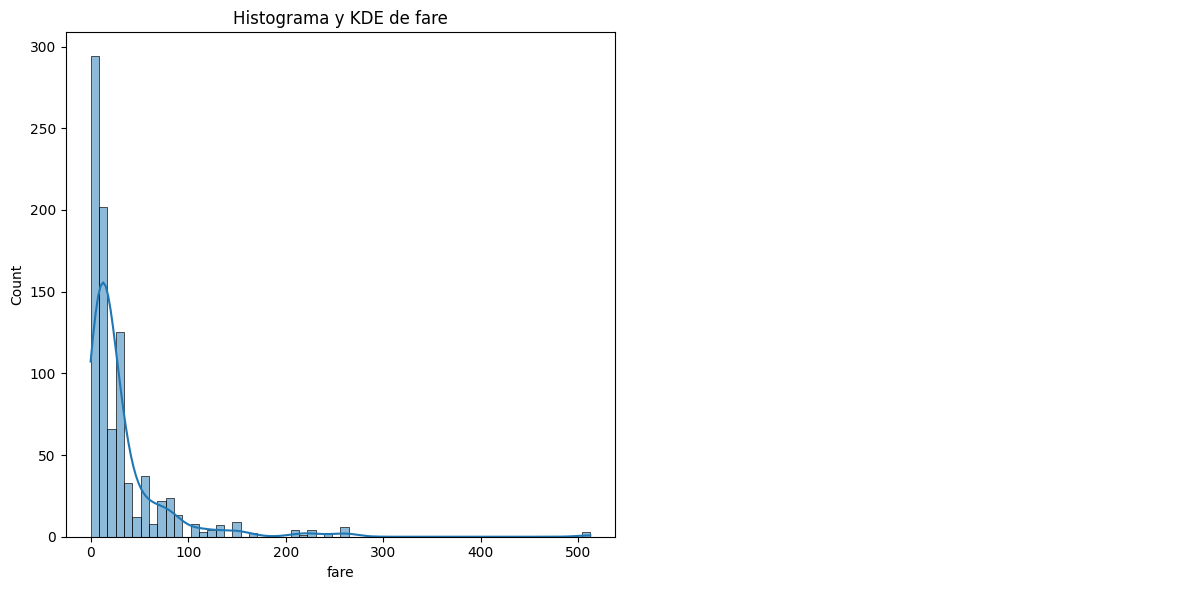

In [96]:
plot_histo_den(df_titanic, ["fare"])

1. Se ve que es Log Normal.




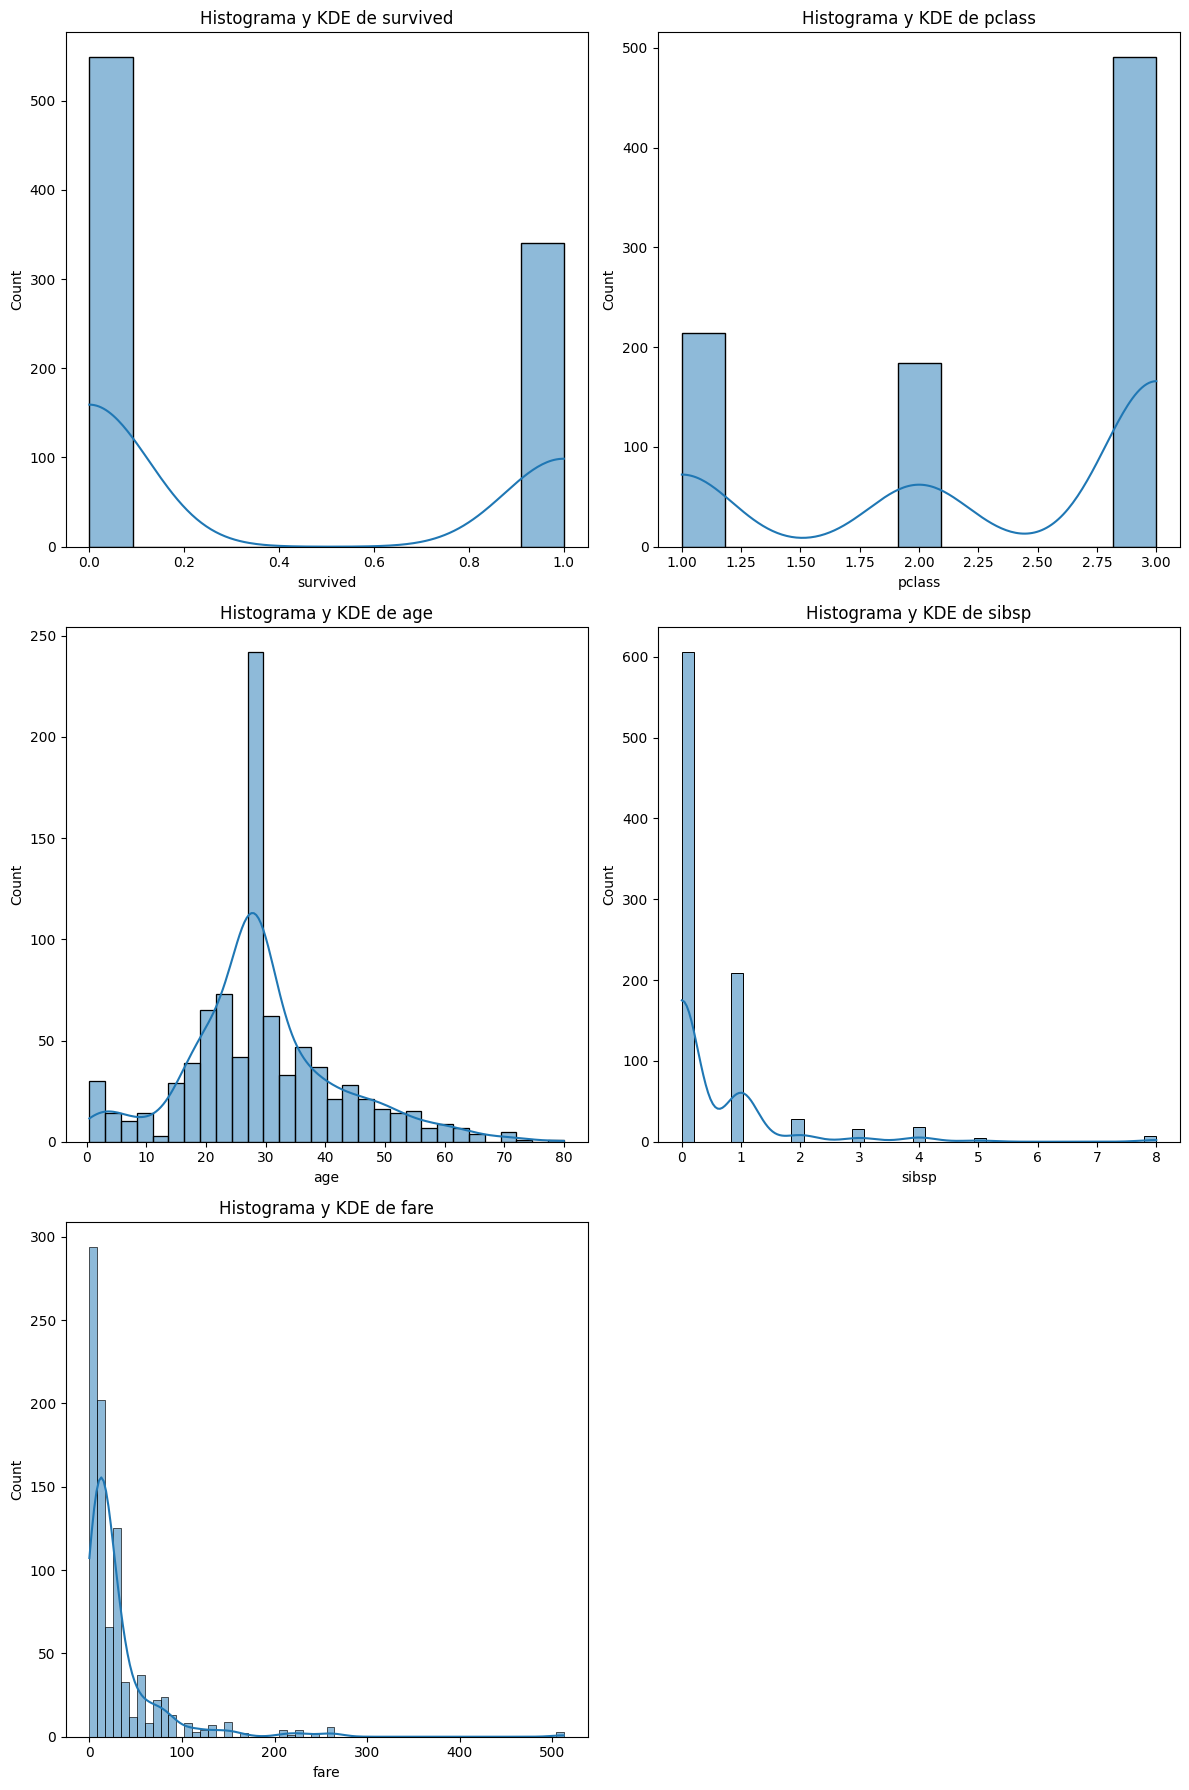

In [97]:
columnas_numericas = df_titanic.describe().columns.to_list()

plot_histo_den(df_titanic,columnas_numericas)

In [99]:
def plot_combined_graphs(df, columns, whisker_width=1.5):
    num_cols = len(columns)
    if num_cols:
        
        fig, axes = plt.subplots(num_cols, 2, figsize=(12, 5 * num_cols))
        print(axes.shape)

        for i, column in enumerate(columns):
            if df[column].dtype in ['int64', 'float64']:
                # Histograma y KDE
                sns.histplot(df[column], kde=True, ax=axes[i,0] if num_cols > 1 else axes[0])
                if num_cols > 1:
                    axes[i,0].set_title(f'Histograma y KDE de {column}')
                else:
                    axes[0].set_title(f'Histograma y KDE de {column}')

                # Boxplot
                sns.boxplot(x=df[column], ax=axes[i,1] if num_cols > 1 else axes[1], whis=whisker_width)
                if num_cols > 1:
                    axes[i,1].set_title(f'Boxplot de {column}')
                else:
                    axes[1].set_title(f'Boxplot de {column}')

        plt.tight_layout()
        plt.show()

(2,)


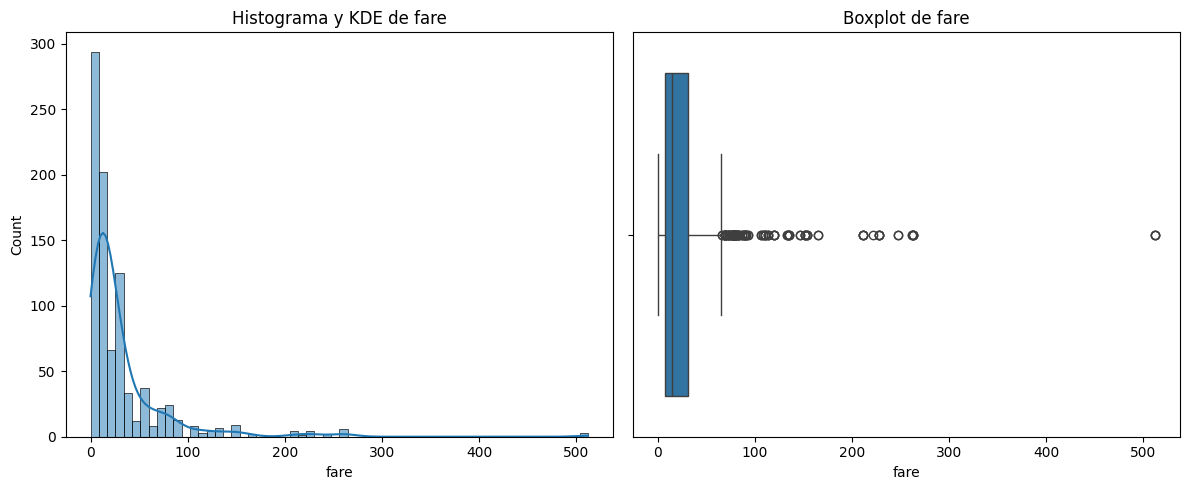

In [100]:
plot_combined_graphs(df_titanic, ["fare"])

(5, 2)


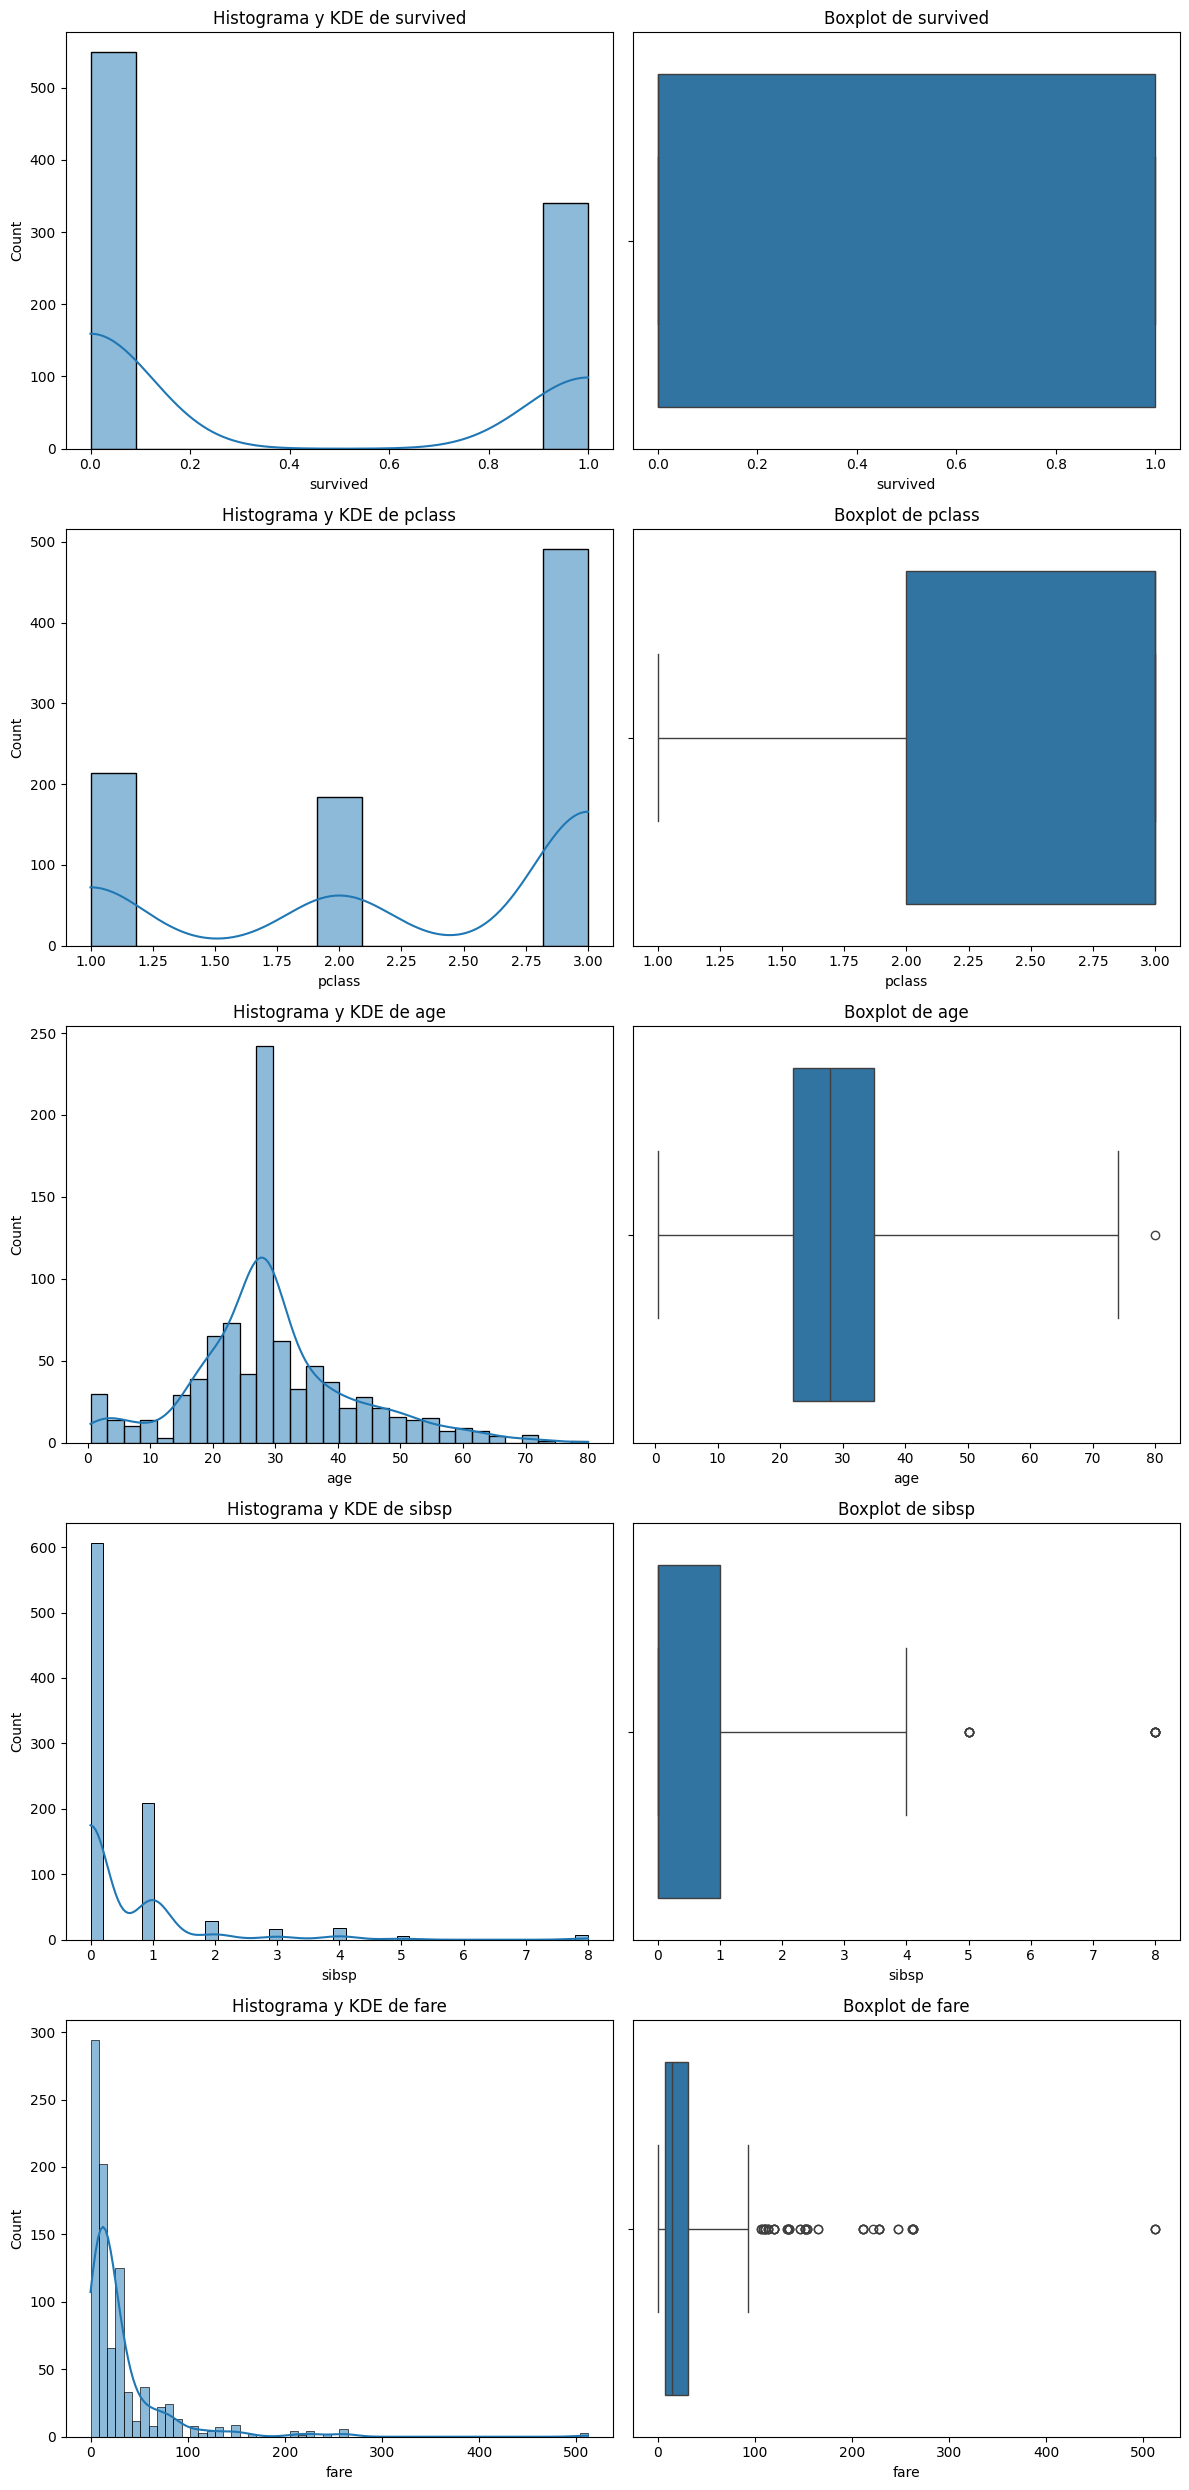

In [102]:
plot_combined_graphs(df_titanic, columns = columnas_numericas, whisker_width=3)